# Goal and Work Summary

**Goal**: Build and evaluate a full-image semantic segmentation pipeline to detect defects in green rough oak planks (Background, BlackRot, Knot, Stain). This notebook uses **Optuna hyperparameter optimization** to find strong training settings, then trains a **ResNet34-DeepLabV3** model and reports test-set metrics with deployment export.

## Workflow Stages and Rationale

**Stage 1 - Data audit and class normalization**
- Scan raw line-scan data and normalize class naming.
- Use reusable helpers in `notebooks/functions`.

**Why this choice**: Consistent labels improve training stability and metric reliability.

**Stage 2 - Class filtering and split preparation**
- Filter low-frequency classes using an explicit threshold.
- Build reproducible train/val/test splits.

**Why this choice**: Better class balance and repeatable experiments.

**Stage 3 - Full-image dataset and augmentations**
- Use full-image dataloading with Albumentations.
- Support non-square image sizes via `IMAGE_HEIGHT` and `IMAGE_WIDTH`.

**Why this choice**: Full context per image and configurable resolution.

**Stage 4 - Optuna hyperparameter tuning**
- Tune batch size, learning rate, weight decay, and optimizer.
- Use TPE sampler + pruning to reduce wasted trials.

**Why this choice**: Automated search usually outperforms manual tuning.

**Stage 5 - Final training with best trial**
- Train DeepLabV3 using best trial parameters.
- Save checkpoints, TensorBoard logs, and history.

**Why this choice**: Preserves reproducibility and best-model recovery.

**Stage 6 - Test-set evaluation**
- Reload best checkpoint and compute confusion matrix, pixel accuracy, F1, IoU, and ROC-AUC.

**Why this choice**: Multi-metric view captures different strengths/failures.

**Stage 7 - ONNX export and verification**
- Export EBI-compliant ONNX with baked-in preprocessing and softmax score scaling.
- Verify input/output signatures with ONNX Runtime.

**Why this choice**: Deployment-ready model artifact and quick correctness checks.

## References (Libraries)

| Library | Purpose | Link |
| --- | --- | --- |
| PyTorch | Training/inference and dataloaders | https://pytorch.org/ |
| segmentation_models_pytorch | DeepLabV3 architecture and encoders | https://github.com/qubvel/segmentation_models.pytorch |
| Optuna | Hyperparameter optimization | https://optuna.org/ |
| Albumentations | Image augmentations and normalization | https://albumentations.ai/ |
| scikit-learn | Evaluation metrics | https://scikit-learn.org/ |
| ONNX Runtime | Export verification | https://onnxruntime.ai/ |

In [2]:
# Prepare dataset + core imports
from functions.data_pipeline import prepare_dataset
import segmentation_models_pytorch as smp
from torch.utils.tensorboard import SummaryWriter
import optuna
from functions.oak_hf_dataset import ensure_oak_raw_data

RAW_DIR = ensure_oak_raw_data()
data_root, class_mapping = prepare_dataset(
    mask_threshold=100,
    val_split=0.16,
    test_split=0.2,
)

PREPARE_DATASET — SKIPPED (data already prepared)
  Organized data: ../data/organized-data
  Classes: {'BlackRot': 1, 'Knot': 2, 'Stain': 3}
  (pass force=True to re-run the full pipeline)


In [3]:
# ──────────────────────────────────────────────
# Configuration - change these knobs as needed
# ──────────────────────────────────────────────
MODEL_ARCH      = "DeepLabV3"
ENCODER_NAME    = "resnet34"
ENCODER_WEIGHTS = "imagenet"

DATA_ROOT       = "../data/organized-data"
IMAGE_HEIGHT    = 384
IMAGE_WIDTH     = 1024
BATCH_SIZE      = 8
NUM_WORKERS     = 4
NUM_CLASSES     = len(class_mapping) + 1  # +1 for Background

# Optuna search controls
N_TRIALS        = 20
OPTUNA_DB_PATH  = "../logs/optuna/DeepLabV3_FullImage_Optuna.db"

# Final training defaults (used after selecting best trial)
LEARNING_RATE   = 1e-3
NUM_EPOCHS      = 50

CHECKPOINT_NAME = "DeepLabV3_FullImage_Optuna"
LOG_NAME        = "ResNet34_DeepLabV3_FullImage_Optuna"
ONNX_NAME       = "deeplabv3_fullimage_optuna.onnx"

In [4]:
from pathlib import Path
import cv2
import numpy as np
from PIL import Image
import json
import torch
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2


class FullImageSegmentationDataset(Dataset):
    def __init__(self, data_root, split="train", transform=None):
        self.data_root = Path(data_root)
        self.split = split
        self.transform = transform

        split_file = self.data_root / "split.json"
        with open(split_file, "r") as f:
            split_info = json.load(f)
        self.image_ids = split_info[split]

        self.images_dir = self.data_root / "images"
        self.masks_dir = self.data_root / "combined_masks"

        print(f"Loaded {split} dataset: {len(self.image_ids)} images (full image mode)")

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_path = self.images_dir / f"{img_id}_Col.tif"
        mask_path = self.masks_dir / f"{img_id}_mask.png"

        image = np.array(Image.open(img_path).convert("RGB"))
        mask = np.array(Image.open(mask_path))

        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]

        return image, mask.long()


def get_training_augmentation_full(image_height=IMAGE_HEIGHT, image_width=IMAGE_WIDTH):
    aug_list = [
        A.Resize(image_height, image_width),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        A.OneOf([A.RandomBrightnessContrast(p=1), A.RandomGamma(p=1)], p=0.3),
        A.OneOf([A.GaussNoise(p=1), A.GaussianBlur(p=1)], p=0.2),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ]
    # RandomRotate90 swaps H/W for non-square inputs and breaks batching.
    if image_height == image_width:
        aug_list.insert(3, A.RandomRotate90(p=0.5))
    return A.Compose(aug_list)


def get_validation_augmentation_full(image_height=IMAGE_HEIGHT, image_width=IMAGE_WIDTH):
    return A.Compose([
        A.Resize(image_height, image_width),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])


def create_dataloaders_full(
    data_root,
    batch_size=BATCH_SIZE,
    num_workers=4,
    image_height=IMAGE_HEIGHT,
    image_width=IMAGE_WIDTH,
):
    train_dataset = FullImageSegmentationDataset(
        data_root=data_root,
        split="train",
        transform=get_training_augmentation_full(image_height=image_height, image_width=image_width),
    )
    val_dataset = FullImageSegmentationDataset(
        data_root=data_root,
        split="val",
        transform=get_validation_augmentation_full(image_height=image_height, image_width=image_width),
    )

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=True,
    )
    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )
    return train_loader, val_loader

In [5]:
# Runtime setup
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CLASS_NAMES = ["Background"] + [
    name for name, _ in sorted(class_mapping.items(), key=lambda x: x[1])
]
assert len(CLASS_NAMES) == NUM_CLASSES, (
    f"CLASS_NAMES ({len(CLASS_NAMES)}) != NUM_CLASSES ({NUM_CLASSES})"
)

print(f"Model architecture: {MODEL_ARCH}")
print(f"Encoder: {ENCODER_NAME}")
print(f"Image size (HxW): {IMAGE_HEIGHT}x{IMAGE_WIDTH}")
print(f"Num classes: {NUM_CLASSES}")
print(f"Optuna trials: {N_TRIALS}")

Model architecture: DeepLabV3
Encoder: resnet34
Image size (HxW): 384x1024
Num classes: 4
Optuna trials: 20


### Model Training Utilities (DeepLabV3)

In [6]:
print("CUDA available:", torch.cuda.is_available())
print("Current device:", torch.cuda.current_device() if torch.cuda.is_available() else "CPU")
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA available: True
Current device: 0
Device name: NVIDIA GeForce RTX 3090


In [7]:
import gc
import torch.nn as nn
from torch.optim import Adam, AdamW

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / CHECKPOINT_NAME
MODEL_DIR = PROJECT_ROOT / "models" / CHECKPOINT_NAME
TENSORBOARD_DIR = PROJECT_ROOT / "logs" / "tensorboard" / LOG_NAME

for d in [CHECKPOINT_DIR, MODEL_DIR, TENSORBOARD_DIR]:
    d.mkdir(parents=True, exist_ok=True)


def build_model(num_classes, encoder_name=ENCODER_NAME, encoder_weights=ENCODER_WEIGHTS):
    model = smp.DeepLabV3(
        encoder_name=encoder_name,
        encoder_weights=encoder_weights,
        in_channels=3,
        classes=num_classes,
    )
    return model.to(DEVICE)


def build_optimizer(params, name, lr, weight_decay):
    if name == "adamw":
        return AdamW(params, lr=lr, weight_decay=weight_decay)
    return Adam(params, lr=lr, weight_decay=weight_decay)


def compute_iou(pred, target, num_classes):
    ious = []
    for cls in range(num_classes):
        pred_mask = (pred == cls)
        target_mask = (target == cls)
        intersection = (pred_mask & target_mask).sum().float()
        union = (pred_mask | target_mask).sum().float()
        iou = intersection / (union + 1e-6)
        ious.append(iou.item())
    return np.mean(ious)


def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    num_batches = 0

    for img_patch, mask_patch in train_loader:
        img_patch = img_patch.to(device)
        mask_patch = mask_patch.to(device)

        logits = model(img_patch)
        loss = criterion(logits, mask_patch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    return total_loss / max(1, num_batches)


def validate(model, val_loader, criterion, device, num_classes):
    model.eval()
    total_loss = 0.0
    total_iou = 0.0
    num_batches = 0

    with torch.no_grad():
        for img_patch, mask_patch in val_loader:
            img_patch = img_patch.to(device)
            mask_patch = mask_patch.to(device)

            logits = model(img_patch)
            loss = criterion(logits, mask_patch)
            pred = torch.argmax(logits, dim=1)
            iou = compute_iou(pred, mask_patch, num_classes)

            total_loss += loss.item()
            total_iou += iou
            num_batches += 1

    return total_loss / max(1, num_batches), total_iou / max(1, num_batches)


def run_training(config, trial=None):
    train_loader, val_loader = create_dataloaders_full(
        data_root=DATA_ROOT,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        image_height=config.get("image_height", IMAGE_HEIGHT),
        image_width=config.get("image_width", IMAGE_WIDTH),
    )

    model = build_model(NUM_CLASSES)
    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(
        model.parameters(),
        name=config.get("optimizer", "adam"),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )

    writer = SummaryWriter(log_dir=config["log_dir"]) if config.get("log_dir") else None

    history = {"train_loss": [], "val_loss": [], "val_iou": []}
    best_val_iou = -1.0
    best_epoch = -1
    patience = config.get("early_stop_patience")
    min_delta = float(config.get("early_stop_min_delta", 0.0))
    epochs_since_improve = 0

    for epoch in range(config["num_epochs"]):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_iou = validate(model, val_loader, criterion, DEVICE, NUM_CLASSES)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_iou"].append(val_iou)

        if config.get("verbose"):
            print(
                f"Epoch {epoch+1}/{config['num_epochs']} | "
                f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.4f}"
            )

        if writer:
            writer.add_scalar("Loss/Train", train_loss, epoch)
            writer.add_scalar("Loss/Val", val_loss, epoch)
            writer.add_scalar("IoU/Val", val_iou, epoch)

        improved = val_iou > best_val_iou + min_delta
        if improved:
            best_val_iou = val_iou
            best_epoch = epoch + 1
            epochs_since_improve = 0
            if config.get("save_checkpoints"):
                best_path = MODEL_DIR / "model_best.pt"
                torch.save(
                    {
                        "epoch": epoch + 1,
                        "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "train_loss": train_loss,
                        "val_loss": val_loss,
                        "val_iou": val_iou,
                    },
                    best_path,
                )
                if config.get("verbose"):
                    print(f"  -> Best checkpoint saved: {best_path}")
        else:
            epochs_since_improve += 1

        if trial is not None:
            trial.report(val_iou, epoch)
            if trial.should_prune():
                if writer:
                    writer.close()
                raise optuna.exceptions.TrialPruned()

        if config.get("save_checkpoints") and ((epoch + 1) % config.get("save_interval", 5) == 0):
            ckpt_path = CHECKPOINT_DIR / f"model_epoch_{epoch+1}.pt"
            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "train_loss": train_loss,
                    "val_loss": val_loss,
                    "val_iou": val_iou,
                },
                ckpt_path,
            )
            if config.get("verbose"):
                print(f"  -> Checkpoint saved: {ckpt_path}")

        if patience is not None and epochs_since_improve >= patience:
            if config.get("verbose"):
                print(f"Early stopping at epoch {epoch+1} (best IoU={best_val_iou:.4f} at epoch {best_epoch})")
            break

    if config.get("save_checkpoints"):
        history_path = CHECKPOINT_DIR / "training_history.json"
        with open(history_path, "w") as f:
            json.dump(history, f, indent=2)
        if config.get("verbose"):
            print(f"\nTraining complete. History saved to {history_path}")

    if writer:
        writer.close()

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return best_val_iou, history

### Optuna Hyperparameter Tuning

Search for strong validation IoU over batch size, learning rate, weight decay, and optimizer choices.

In [8]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

optuna_db = Path(OPTUNA_DB_PATH)
optuna_db.parent.mkdir(parents=True, exist_ok=True)
OPTUNA_STORAGE = f"sqlite:///{optuna_db.resolve()}"
STUDY_NAME = "deeplabv3_fullimage_optuna"

sampler = optuna.samplers.TPESampler(seed=42, multivariate=True)
pruner = optuna.pruners.MedianPruner(n_warmup_steps=3)


def objective(trial):
    config = {
        "lr": trial.suggest_float("lr", 1e-5, 3e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
        "optimizer": trial.suggest_categorical("optimizer", ["adam", "adamw"]),
        "num_epochs": 40,
        "early_stop_patience": 5,
        "early_stop_min_delta": 1e-3,
        "image_height": IMAGE_HEIGHT,
        "image_width": IMAGE_WIDTH,
        "save_checkpoints": False,
        "verbose": False,
    }
    best_val_iou, _ = run_training(config, trial=trial)
    return best_val_iou


study = optuna.create_study(
    direction="maximize",
    study_name=STUDY_NAME,
    storage=OPTUNA_STORAGE,
    load_if_exists=True,
    sampler=sampler,
    pruner=pruner,
)

study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=True,
    gc_after_trial=True,
    catch=(RuntimeError,),
)

print("Best trial:")
print("  Value (val_iou):", study.best_trial.value)
print("  Params:", study.best_trial.params)

/usr/local/lib/python3.10/dist-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(


  0%|          | 0/20 [00:00<?, ?it/s]

/home/vscode/.local/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Loaded train dataset: 433 images (full image mode)
Loaded val dataset: 83 images (full image mode)
Loaded train dataset: 433 images (full image mode)
Loaded val dataset: 83 images (full image mode)
Loaded train dataset: 433 images (full image mode)
Loaded val dataset: 83 images (full image mode)
Loaded train dataset: 433 images (full image mode)
Loaded val dataset: 83 images (full image mode)
Loaded train dataset: 433 images (full image mode)
Loaded val dataset: 83 images (full image mode)
Loaded train dataset: 433 images (full image mode)
Loaded val dataset: 83 images (full image mode)
Loaded train dataset: 433 images (full image mode)
Loaded val dataset: 83 images (full image mode)
Loaded train dataset: 433 images (full image mode)
Loaded val dataset: 83 images (full image mode)
Loaded train dataset: 433 images (full image mode)
Loaded val dataset: 83 images (full image mode)
Loaded train dataset: 433 images (full image mode)
Loaded val dataset: 83 images (full image mode)
Loaded tra

### Train Final Model With Best Hyperparameters

Train DeepLabV3 with the selected trial and save best/periodic checkpoints.

In [9]:
best_params = study.best_trial.params

final_config = {
    "batch_size": BATCH_SIZE,
    "lr": best_params["lr"],
    "weight_decay": best_params["weight_decay"],
    "optimizer": best_params["optimizer"],
    "num_epochs": NUM_EPOCHS,
    "early_stop_patience": 10,
    "early_stop_min_delta": 1e-4,
    "image_height": IMAGE_HEIGHT,
    "image_width": IMAGE_WIDTH,
    "save_checkpoints": True,
    "save_interval": 5,
    "log_dir": str(TENSORBOARD_DIR),
    "verbose": True,
}

best_val_iou, history = run_training(final_config)
print(f"Final training complete. Best Val IoU: {best_val_iou:.4f}")

Loaded train dataset: 433 images (full image mode)
Loaded val dataset: 83 images (full image mode)
Epoch 1/50 | Train Loss: 1.0072 | Val Loss: 2.1468 | Val IoU: 0.2678
  -> Best checkpoint saved: /workspaces/Oak-Defect-Detection/models/DeepLabV3_FullImage_Optuna/model_best.pt
Epoch 2/50 | Train Loss: 0.6076 | Val Loss: 0.5497 | Val IoU: 0.3886
  -> Best checkpoint saved: /workspaces/Oak-Defect-Detection/models/DeepLabV3_FullImage_Optuna/model_best.pt
Epoch 3/50 | Train Loss: 0.4852 | Val Loss: 0.4831 | Val IoU: 0.3917
  -> Best checkpoint saved: /workspaces/Oak-Defect-Detection/models/DeepLabV3_FullImage_Optuna/model_best.pt
Epoch 4/50 | Train Loss: 0.4219 | Val Loss: 0.4535 | Val IoU: 0.4112
  -> Best checkpoint saved: /workspaces/Oak-Defect-Detection/models/DeepLabV3_FullImage_Optuna/model_best.pt
Epoch 5/50 | Train Loss: 0.3661 | Val Loss: 0.3546 | Val IoU: 0.4645
  -> Best checkpoint saved: /workspaces/Oak-Defect-Detection/models/DeepLabV3_FullImage_Optuna/model_best.pt
  -> Checkp

In [10]:
# Create test loader
test_dataset = FullImageSegmentationDataset(
    data_root=DATA_ROOT,
    split="test",
    transform=get_validation_augmentation_full(image_height=IMAGE_HEIGHT, image_width=IMAGE_WIDTH),
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print(f"Loaded test dataset: {len(test_dataset)} images")

Loaded test dataset: 129 images (full image mode)
Loaded test dataset: 129 images


In [11]:
# Load best model for evaluation
best_model_path = MODEL_DIR / "model_best.pt"

model = smp.DeepLabV3(
    encoder_name=ENCODER_NAME,
    encoder_weights=None,
    in_channels=3,
    classes=NUM_CLASSES,
).to(DEVICE)

ckpt = torch.load(best_model_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print(f"Loaded best model: {best_model_path}")
print(f"Checkpoint epoch={ckpt.get('epoch')} | val_iou={ckpt.get('val_iou'):.4f}")

Loaded best model: /workspaces/Oak-Defect-Detection/models/DeepLabV3_FullImage_Optuna/model_best.pt
Checkpoint epoch=49 | val_iou=0.5575


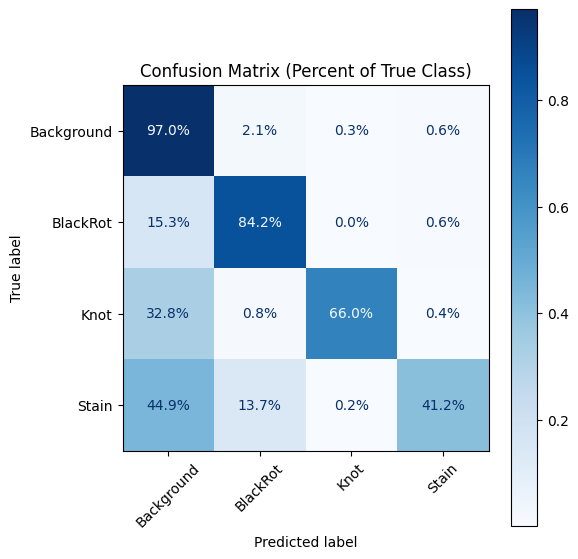

Accuracy: 0.9233
F1 per class:
  Background: 0.9599
  BlackRot: 0.7961
  Knot: 0.6556
  Stain: 0.5472
F1 Macro: 0.7397
IoU per class:
  Background: 0.9229
  BlackRot: 0.6613
  Knot: 0.4877
  Stain: 0.3767
Mean IoU (excl background): 0.5086


/tmp/ipykernel_75164/3084272089.py:75: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


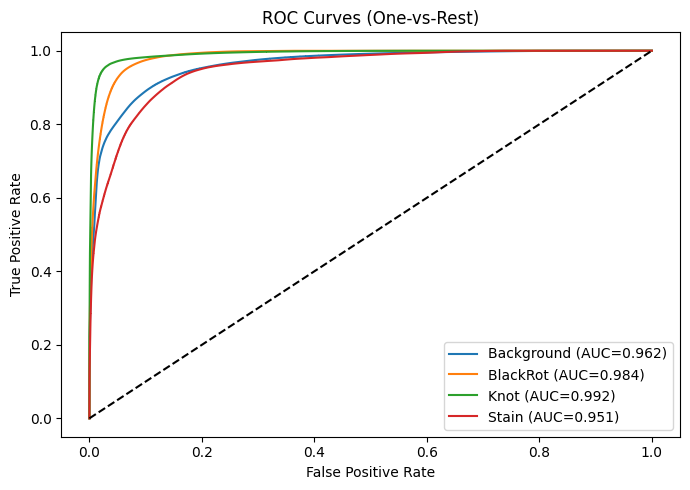

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, roc_curve, auc
from sklearn.metrics import ConfusionMatrixDisplay

all_preds = []
all_targets = []
all_probs = []

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.append(preds.cpu().numpy().reshape(-1))
        all_targets.append(masks.cpu().numpy().reshape(-1))
        all_probs.append(probs.cpu().numpy().transpose(0, 2, 3, 1).reshape(-1, NUM_CLASSES))

all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)
all_probs = np.concatenate(all_probs)

cm = confusion_matrix(all_targets, all_preds, labels=list(range(NUM_CLASSES)))
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format=".1%", colorbar=True, xticks_rotation=45)
plt.title("Confusion Matrix (Percent of True Class)")
plt.tight_layout()
plt.show()

acc = accuracy_score(all_targets, all_preds)
print(f"Accuracy: {acc:.4f}")

f1_per_class = f1_score(all_targets, all_preds, labels=list(range(NUM_CLASSES)), average=None)
f1_macro = f1_score(all_targets, all_preds, labels=list(range(NUM_CLASSES)), average="macro")
print("F1 per class:")
for i, f1 in enumerate(f1_per_class):
    print(f"  {CLASS_NAMES[i]}: {f1:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")

intersection = np.diag(cm).astype(np.float32)
union = cm.sum(axis=0) + cm.sum(axis=1) - intersection
iou_per_class = np.divide(intersection, union, out=np.zeros_like(intersection), where=union != 0)
print("IoU per class:")
for i, iou in enumerate(iou_per_class):
    print(f"  {CLASS_NAMES[i]}: {iou:.4f}")

mean_iou_excl_bg = iou_per_class[1:].mean() if NUM_CLASSES > 1 else iou_per_class.mean()
print(f"Mean IoU (excl background): {mean_iou_excl_bg:.4f}")

plt.figure(figsize=(7, 5))
for c in range(NUM_CLASSES):
    y_true_bin = (all_targets == c).astype(int)
    y_score = all_probs[:, c]

    if y_true_bin.sum() == 0:
        print(f"ROC skipped: {CLASS_NAMES[c]} (no positives in test set)")
        continue

    fpr, tpr, _ = roc_curve(y_true_bin, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{CLASS_NAMES[c]} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import torch.nn.functional as F
import torch.onnx


class EBIExportWrapper(nn.Module):
    """
    Input:  uint8  [B, 3, H, W]  (raw RGB 0-255)
    Output: float32 [B, C, H, W] (per-pixel class scores 0-100%)
    """

    def __init__(self, seg_model, mean=None, std=None):
        super().__init__()
        self.seg_model = seg_model
        if mean is None:
            mean = [0.485, 0.456, 0.406]
        if std is None:
            std = [0.229, 0.224, 0.225]
        self.register_buffer("mean", torch.tensor(mean, dtype=torch.float32).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor(std, dtype=torch.float32).view(1, 3, 1, 1))

    def forward(self, x):
        x = x.float() / 255.0
        x = (x - self.mean) / self.std
        logits = self.seg_model(x)
        probs = F.softmax(logits, dim=1)
        return probs * 100.0


onnx_dir = PROJECT_ROOT / "models" / "onnx"
onnx_dir.mkdir(parents=True, exist_ok=True)
onnx_path = onnx_dir / ONNX_NAME

ebi_model = EBIExportWrapper(model).to(DEVICE)
ebi_model.eval()

dummy_input = torch.randint(0, 256, (1, 3, IMAGE_HEIGHT, IMAGE_WIDTH), dtype=torch.uint8, device=DEVICE)

torch.onnx.export(
    ebi_model,
    dummy_input,
    onnx_path.as_posix(),
    input_names=["input"],
    output_names=["output"],
    opset_version=12,
    dynamic_axes={
        "input": {0: "batch", 2: "height", 3: "width"},
        "output": {0: "batch", 2: "height", 3: "width"},
    },
)

print(f"Exported ONNX model to: {onnx_path}")
print("  Input:  uint8  [B, 3, H, W]  (raw RGB 0-255)")
print("  Output: float32 [B, C, H, W] (per-pixel class scores 0-100%)")

import onnxruntime as ort

session = ort.InferenceSession(onnx_path.as_posix())
inp_meta = session.get_inputs()[0]
out_meta = session.get_outputs()[0]
print(f"ONNX Input:  name={inp_meta.name}, shape={inp_meta.shape}, type={inp_meta.type}")
print(f"ONNX Output: name={out_meta.name}, shape={out_meta.shape}, type={out_meta.type}")

test_input = np.random.randint(0, 256, (1, 3, IMAGE_HEIGHT, IMAGE_WIDTH)).astype(np.uint8)
onnx_output = session.run(None, {inp_meta.name: test_input})[0]
print(f"Output range: [{onnx_output.min():.2f}, {onnx_output.max():.2f}]")
print(f"Class-sum range: min={onnx_output.sum(axis=1).min():.2f}, max={onnx_output.sum(axis=1).max():.2f}")
print("ONNX verification passed")

/tmp/ipykernel_75164/30752687.py:38: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0409 18:46:23.167000 75164 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0409 18:46:23.626000 75164 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, 

[torch.onnx] Obtain model graph for `EBIExportWrapper([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EBIExportWrapper([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.10/copyreg.py:101: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.10/site-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
  File "/home/vscode/.local/lib/python3.10/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "/home/vscode/.local/lib/python3.10/site-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
  File "/home/vscode/.local/lib/python3.10/site-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:65: adapt: Assertion `node->hasAttribute(kaxes)` failed: No initializer or co

Applied 86 of general pattern rewrite rules.
Exported ONNX model to: /workspaces/Oak-Defect-Detection/models/onnx/deeplabv3_fullimage_optuna.onnx
  Input:  uint8  [B, 3, H, W]  (raw RGB 0-255)
  Output: float32 [B, C, H, W] (per-pixel class scores 0-100%)
ONNX Input:  name=image, shape=['batch', 3, 'height', 'width'], type=tensor(uint8)
ONNX Output: name=scores, shape=['batch', 4, '8*(((height - 1)//8)) + 8', '8*(((width - 1)//8)) + 8'], type=tensor(float)
Output range: [0.16, 98.48]
Class-sum range: min=100.00, max=100.00
ONNX verification passed
